In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("/content/Final_CAPM_Dataset.xlsx")

In [7]:
#چون داده ها روزانه است و به دلیل وجود دامنه نوسان داده های روزانه مناسب نیست تبدیل به ماهانه میکنیم
df["yearandmonth"] = df['Date'].astype(str).str[:7]
df_month = df.groupby("yearandmonth").last().reset_index()
print("تعداد داده های ماهانه :",len(df_month))

تعداد داده های ماهانه : 98


In [11]:
#محاسبه بازده
df_month["market return monthly"] = df_month["Market_Index"].pct_change()
df_month["fameli return monthly"] = df_month["Fameli_Close"].pct_change()
df_month = df_month.dropna()
df_month.head(6)

/tmp/ipykernel_633/1657645723.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_month["market return monthly"] = df_month["Market_Index"].pct_change()
/tmp/ipykernel_633/1657645723.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_month["fameli return monthly"] = df_month["Fameli_Close"].pct_change()


,yearandmonth,Date,Market_Index,Market_Return,Fameli_Close,Fameli_Return,market return monthly,fameli return monthly
3,1397/06,1397/06/31,165072.0,0.028243,4025,0.034704,0.205697,0.011052
4,1397/07,1397/07/30,185318.0,-0.013101,4579,-0.003482,0.122650,0.137640
5,1397/08,1397/08/29,175713.0,-0.004222,4013,0.003752,-0.051830,-0.123608
6,1397/09,1397/09/27,156083.0,-0.019246,3744,0.000000,-0.111716,-0.067032
7,1397/10,1397/10/30,161922.0,-0.022063,2779,-0.008562,0.037410,-0.257746
8,1397/11,1397/11/30,159489.0,0.013356,2955,0.044908,-0.015026,0.063332


In [12]:
cov = df_month['fameli return monthly'].cov(df_month['market return monthly'])
var = df_month["market return monthly"].var()
beta = cov/var
print(f"بتای ماهانه فملی: {beta:.2f}")

بتای ماهانه فملی: 1.12


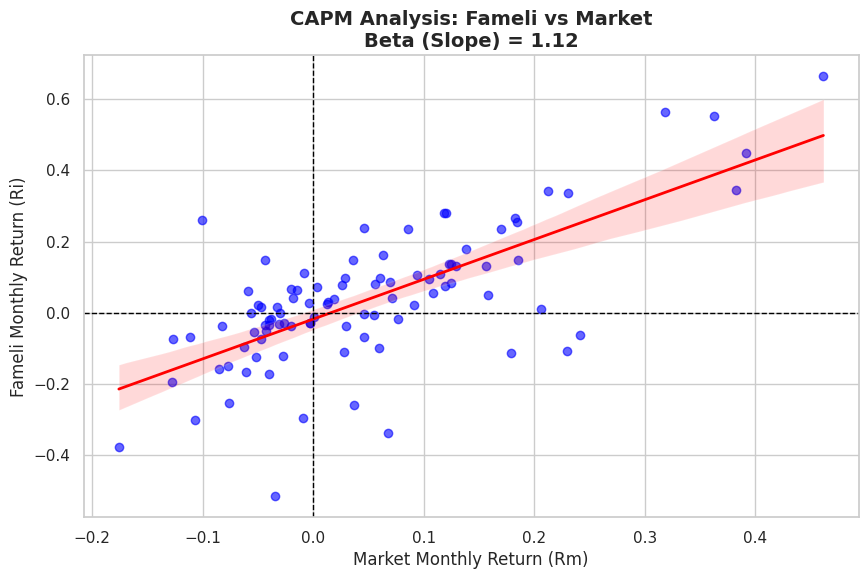

In [15]:
plt.figure(figsize=(10,6))
sns.set_theme(style='whitegrid')
sns.regplot(
    x = "market return monthly",
    y = "fameli return monthly",
    data=df_month,
    scatter_kws={"alpha":0.6,"color": "blue"},
    line_kws={"color": "red", 'linewidth':2}
)
plt.title(f"CAPM Analysis: Fameli vs Market\nBeta (Slope) = {beta:.2f}", fontsize=14, fontweight='bold')
plt.xlabel("Market Monthly Return (Rm)", fontsize=12)
plt.ylabel("Fameli Monthly Return (Ri)", fontsize=12)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.savefig("CAPM_Beta_Plot.png", dpi=300, bbox_inches='tight')
plt.show()